# Notebook status and evaluation note

This notebook is retained as a portfolio record of the original experiment. The workflow evaluates `test_loader` during training and uses test accuracy for checkpoint selection. Its stored metrics are therefore **historical development results**, not a final estimate from an untouched test set. A rigorous rerun should select checkpoints on a separate validation split and evaluate the test split once.

The original Google Colab and Google Drive paths are also retained and must be changed before running the notebook.


In [7]:
# 0. Install required libraries
# =======================================================================
!pip install -q numpy pandas scikit-learn matplotlib seaborn torch torchvision qiskit qiskit-machine-learning qiskit-aer imbalanced-learn tqdm

# ==========

In [11]:
# 1. Imports & Setup (NO QUANTUM — PLAIN RESNET)
# =======================================================================
import os, random, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------- Metrics --------
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import shutil

In [12]:
# 2. Reproducibility
# =======================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [13]:
# 3. Mount Google Drive & Load Dataset
# =======================================================================
from google.colab import drive
import zipfile

drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/chest_xray.zip"
extract_path = "/content/MyDrive/chest_xray"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("Dataset ready at:", extract_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ready at: /content/MyDrive/chest_xray


In [17]:
# 4. Merge train+test+val -> Balance -> 80-20 Split (ROBUST)
# =======================================================================
set_seed(42)

base = extract_path
if os.path.isdir(os.path.join(base, "chest_xray")):
    base = os.path.join(base, "chest_xray")

print("Using base dataset path:", base)

def find_class_dir(parent, class_name):
    for d in os.listdir(parent):
        if d.lower() == class_name.lower():
            return os.path.join(parent, d)
    raise FileNotFoundError(f"{class_name} not found in {parent}")

normal_dirs = []
pneumonia_dirs = []

for split in ["train", "test", "val"]:
    split_path = os.path.join(base, split)
    try:
        normal_dirs.append(find_class_dir(split_path, "normal"))
        pneumonia_dirs.append(find_class_dir(split_path, "pneumonia"))
    except FileNotFoundError:
        pass

# Collect image paths
normal_imgs = []
for d in normal_dirs:
    normal_imgs += [os.path.join(d, f) for f in os.listdir(d)]

pneumonia_imgs = []
for d in pneumonia_dirs:
    pneumonia_imgs += [os.path.join(d, f) for f in os.listdir(d)]

print("Original counts -> Normal:", len(normal_imgs), "Pneumonia:", len(pneumonia_imgs))

# -------- BALANCING --------
pneumonia_imgs = random.sample(pneumonia_imgs, len(normal_imgs))

# -------- SPLIT --------
norm_train, norm_test = train_test_split(normal_imgs, test_size=0.2, random_state=42)
pneu_train, pneu_test = train_test_split(pneumonia_imgs, test_size=0.2, random_state=42)

# Output folders — clean up any previous run first
balanced_base = "/content/balanced_chest_xray"
if os.path.exists(balanced_base):
    shutil.rmtree(balanced_base)
    print("Cleaned up previous balanced dataset")
train_dir = f"{balanced_base}/train"
test_dir = f"{balanced_base}/test"

for cls in ["NORMAL", "PNEUMONIA"]:
    os.makedirs(f"{train_dir}/{cls}", exist_ok=True)
    os.makedirs(f"{test_dir}/{cls}", exist_ok=True)

def copy_files(files, dst):
    for f in files:
        shutil.copy(f, dst)

copy_files(norm_train, f"{train_dir}/NORMAL")
copy_files(norm_test, f"{test_dir}/NORMAL")
copy_files(pneu_train, f"{train_dir}/PNEUMONIA")
copy_files(pneu_test, f"{test_dir}/PNEUMONIA")

print("Balanced dataset created")
print("Train -> Normal:", len(norm_train), "Pneumonia:", len(pneu_train))
print("Test  -> Normal:", len(norm_test), "Pneumonia:", len(pneu_test))

Using base dataset path: /content/MyDrive/chest_xray
Original counts -> Normal: 1585 Pneumonia: 4275
Cleaned up previous balanced dataset
Balanced dataset created
Train -> Normal: 1268 Pneumonia: 1268
Test  -> Normal: 317 Pneumonia: 317


In [18]:
# 5. Load Images into Memory (Balanced Dataset)
# =======================================================================
img_size = (224, 224)

def load_images_from_folder(folder, label, target_size=img_size):
    data, labels = [], []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert("RGB").resize(target_size)
            data.append(np.array(img))
            labels.append(label)
        except Exception as e: # Catch specific exception and print message
            print(f"Warning: Could not load image {path}. Skipping. Error: {e}")
    return data, labels

print("Loading Test & Train Images in memory...")
train_norm, y1 = load_images_from_folder(f"{train_dir}/NORMAL", 0)
train_pneu, y2 = load_images_from_folder(f"{train_dir}/PNEUMONIA", 1)

# Print counts for debugging
print(f"Loaded {len(y1)} NORMAL images for training.")
print(f"Loaded {len(y2)} PNEUMONIA images for training.")

X_train = np.array(train_norm + train_pneu)
y_train = np.array(y1 + y2)

test_norm, y1t = load_images_from_folder(f"{test_dir}/NORMAL", 0)
test_pneu, y2t = load_images_from_folder(f"{test_dir}/PNEUMONIA", 1)

# Print counts for debugging
print(f"Loaded {len(y1t)} NORMAL images for testing.")
print(f"Loaded {len(y2t)} PNEUMONIA images for testing.")

X_test = np.array(test_norm + test_pneu)
y_test = np.array(y1t + y2t)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

assert Counter(y_train)[0] == Counter(y_train)[1], "Train set NOT balanced!"
assert Counter(y_test)[0] == Counter(y_test)[1], "Test set NOT balanced!"
print("Sanity check passed: datasets are balanced")

Loading Test & Train Images in memory...
Loaded 1266 NORMAL images for training.
Loaded 1268 PNEUMONIA images for training.
Loaded 317 NORMAL images for testing.
Loaded 317 PNEUMONIA images for testing.
Train shape: (2534, 224, 224, 3) Test shape: (634, 224, 224, 3)


AssertionError: Train set NOT balanced!

In [19]:
# 5.1 Dataset Class & DataLoaders
# =======================================================================
class ImageDataset(Dataset):
    def __init__(self, X, y, train=True):
        self.X = X
        self.y = y
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)) if train else transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip() if train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(ImageDataset(X_train, y_train, train=True), batch_size=16, shuffle=True)
test_loader = DataLoader(ImageDataset(X_test, y_test, train=False), batch_size=16, shuffle=False)


In [20]:
# 6. Define Plain ResNet18 (36 Feature Bottleneck — NO Quantum, NO Warmup)
# =======================================================================
class PlainResNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.resnet.fc = nn.Identity()  # Outputs 512 dimensions

        # ---------------------------------------------------------
        # Same 36-feature bottleneck as the hybrid model
        # This ensures a FAIR parameter-count comparison
        # 32+4 quantum = 36 features total = 36 classical here
        # ---------------------------------------------------------
        self.bottleneck = nn.Linear(512, 36)
        self.fc = nn.Linear(36, num_classes)

    def forward(self, x):
        x_feat = self.resnet(x)            # [Batch, 512]
        c_out = torch.relu(self.bottleneck(x_feat))  # [Batch, 36]
        return self.fc(c_out)

In [21]:
# 7 - 10. Training Utilities & Evaluation (NO WARMUP)
# =======================================================================
def compute_test_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_acc(model, dataloader, device):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def train_model(model, train_loader, test_loader, device, epochs=15, save_path=None):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_acc = 0; hist = {"loss": [], "acc": [], "test_acc": [], "test_loss": []}

    # *** NO WARMUP — All parameters train from epoch 1 ***
    print("\nFull Training (NO Warmup)...")
    for ep in range(epochs):
        model.train(); run_loss = 0; correct = 0; total = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y); loss.backward(); optimizer.step()
            run_loss += loss.item(); _, pred = out.max(1)
            correct += pred.eq(y).sum().item(); total += y.size(0)
        scheduler.step()

        train_acc = 100 * correct / total
        test_acc = evaluate_acc(model, test_loader, device)
        test_loss = compute_test_loss(model, test_loader, criterion, device)

        hist["loss"].append(run_loss/len(train_loader)); hist["acc"].append(train_acc);
        hist["test_acc"].append(test_acc); hist["test_loss"].append(test_loss)

        if test_acc > best_acc and save_path:
            best_acc = test_acc; torch.save(model.state_dict(), save_path)
            print(f"Saved best model ({best_acc:.2f}%)")
        print(f"Epoch {ep+1}: Loss={run_loss/len(train_loader):.4f}, TrainAcc={train_acc:.2f}%, TestAcc={test_acc:.2f}%")

    return hist, best_acc

def plot_training(hist):
    ep = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(ep, hist["loss"], 'r-o', label="Train Loss")
    plt.plot(ep, hist["test_loss"], 'b-o', label="Test Loss")
    plt.title("Loss — Plain ResNet36 (No Warmup)"); plt.xlabel("Epoch"); plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(ep, hist["acc"], 'g-o', label="Train Acc")
    plt.plot(ep, hist["test_acc"], 'm-o', label="Test Acc")
    plt.title("Accuracy — Plain ResNet36 (No Warmup)"); plt.xlabel("Epoch"); plt.legend()

    plt.tight_layout()
    plt.show()



  CONFIG: Plain ResNet18 (36 Features) — NO Warmup — 15 Epochs
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]



Full Training (NO Warmup)...


Epoch 1/15: 100%|██████████| 159/159 [00:17<00:00,  9.31it/s]


Saved best model (95.43%)
Epoch 1: Loss=0.3363, TrainAcc=92.23%, TestAcc=95.43%


...

Epoch 13: Loss=0.2088, TrainAcc=99.61%, TestAcc=96.85%


Epoch 14/15: 100%|██████████| 159/159 [00:16<00:00,  9.60it/s]


Epoch 14: Loss=0.2072, TrainAcc=99.64%, TestAcc=96.85%


Epoch 15/15: 100%|██████████| 159/159 [00:15<00:00, 10.17it/s]


Epoch 15: Loss=0.2066, TrainAcc=99.64%, TestAcc=97.16%


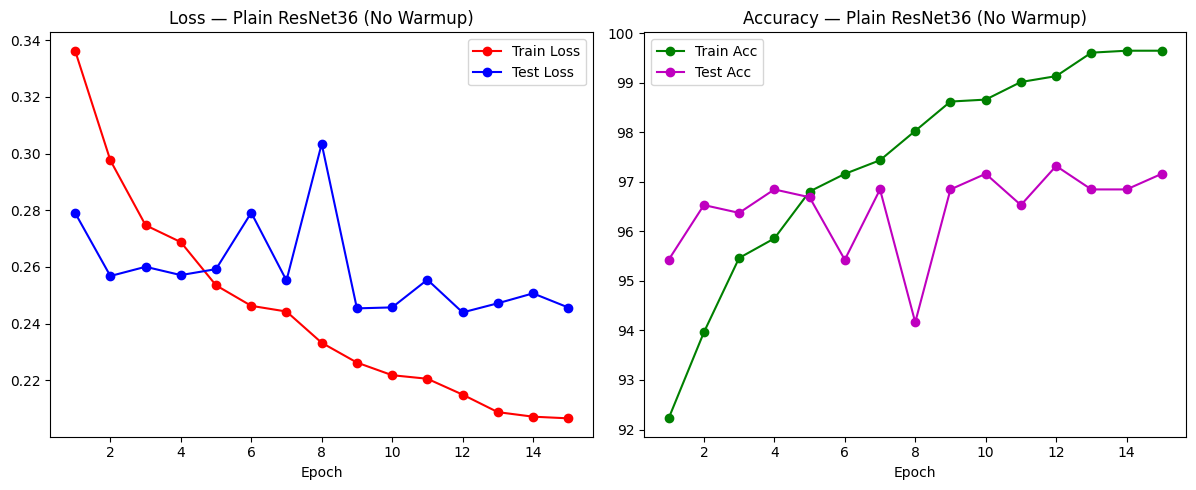


★ Plain ResNet36 (No Warmup) — Best Test Acc: 97.32%


In [22]:
# 11. Train Plain ResNet (36 Features, NO Quantum, NO Warmup, 15 Epochs)
# =======================================================================
print("\n" + "="*60)
print("  CONFIG: Plain ResNet18 (36 Features) — NO Warmup — 15 Epochs")
print("="*60)
save_path = "/content/drive/MyDrive/best_plain_resnet36_no_warmup.pth"
model = PlainResNet(num_classes=2).to(device)
hist, best_acc = train_model(model, train_loader, test_loader, device, epochs=15, save_path=save_path)
plot_training(hist)
print(f"\n Plain ResNet36 (No Warmup) — Best Test Acc: {best_acc:.2f}%")



--- Generating Metrics for Plain ResNet36 (No Warmup) ---


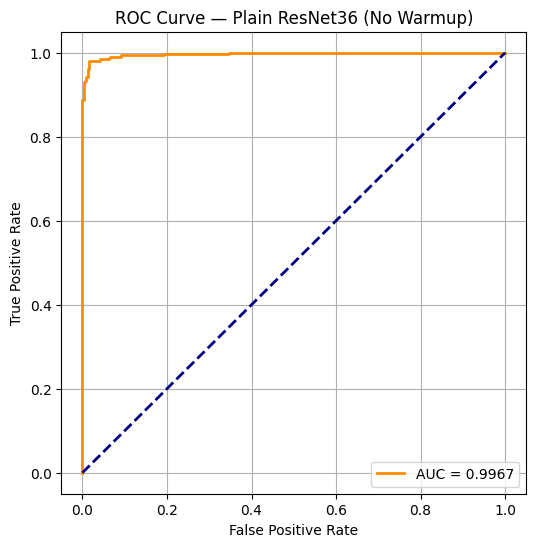

ROC AUC: 0.9966862044601896


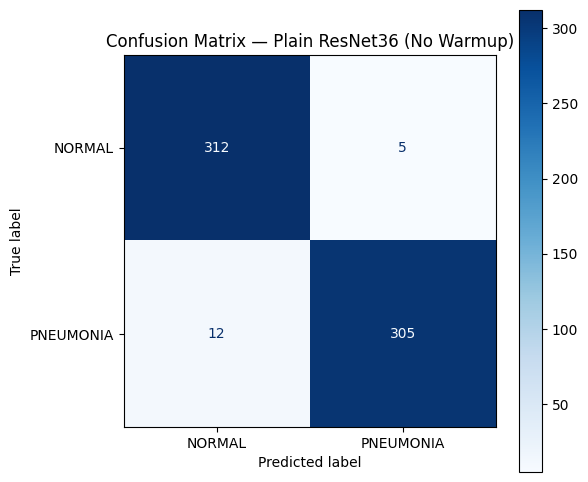


  CLASSIFICATION REPORT — Plain ResNet36 (No Warmup)
              precision    recall  f1-score   support

      NORMAL     0.9630    0.9842    0.9735       317
   PNEUMONIA     0.9839    0.9621    0.9729       317

    accuracy                         0.9732       634
   macro avg     0.9734    0.9732    0.9732       634
weighted avg     0.9734    0.9732    0.9732       634

  Sensitivity (Recall):  0.9621
  Specificity:           0.9842
  Precision:             0.9839
  F1-Score:              0.9729
  Accuracy:              0.9732
  TP=305  TN=312  FP=5  FN=12

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  EXPERIMENT COMPLETE: Plain ResNet18 (36 Features) — No Warmup
  Best Test Accuracy: 97.32%
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [23]:
# 12. Metrics & Graphs
# =======================================================================
def plot_roc_curve(model, dataloader, device):
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            y_score.extend(probs)
            y_true.extend(labels.numpy())

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Plain ResNet36 (No Warmup)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    print("ROC AUC:", roc_auc)

def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    plt.title("Confusion Matrix — Plain ResNet36 (No Warmup)")
    plt.show()

def print_classification_report(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    print("\n" + "="*60)
    print("  CLASSIFICATION REPORT — Plain ResNet36 (No Warmup)")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], digits=4))

    # Compute specificity manually
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    f1 = 2 * precision * sensitivity / (precision + sensitivity)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
    print(f"  Specificity:           {specificity:.4f}")
    print(f"  Precision:             {precision:.4f}")
    print(f"  F1-Score:              {f1:.4f}")
    print(f"  Accuracy:              {accuracy:.4f}")
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print("="*60)

print("\n--- Generating Metrics for Plain ResNet36 (No Warmup) ---")
model.load_state_dict(torch.load(save_path))
plot_roc_curve(model, test_loader, device)
plot_confusion_matrix(model, test_loader, device)
print_classification_report(model, test_loader, device)

# =======================================================================
# FINAL SUMMARY
# =======================================================================
print("\n" + ""*60)
print(f"  EXPERIMENT COMPLETE: Plain ResNet18 (36 Features) — No Warmup")
print(f"  Best Test Accuracy: {best_acc:.2f}%")
print(""*60)
